# Day 8 – LSTM Sentiment Analysis
**Task:** Binary sentiment classification (Positive / Negative) on the IMDB Movie Reviews dataset  
**Framework:** PyTorch  
**Model:** Embedding → Bidirectional LSTM → Fully Connected  
**Target Accuracy:** ~87%

---
### Pipeline Overview
1. Install & Import dependencies
2. Load & preprocess the IMDB dataset
3. Build vocabulary + numericalize text
4. Define the LSTM model
5. Train the model
6. Evaluate on test set
7. Run inference on custom sentences

## 1. Install & Import

In [1]:

!pip install torch torchtext datasets -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.0 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from datasets import load_dataset
from collections import Counter
import numpy as np
import re
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Load & Explore the IMDB Dataset

In [3]:
# Load IMDB dataset from HuggingFace datasets library
# 25,000 train samples | 25,000 test samples | Labels: 0=negative, 1=positive
dataset = load_dataset('imdb')

print('Dataset structure:')
print(dataset)
print()
print('Sample review:')
print(dataset['train'][0]['text'][:300], '...')
print('Label:', 'Positive' if dataset['train'][0]['label'] == 1 else 'Negative')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Sample review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h ...
Label: Negative


## 3. Text Preprocessing & Vocabulary Building

In [4]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
MAX_VOCAB_SIZE  = 25_000   # keep only the top 25k most frequent tokens
MAX_SEQ_LEN     = 256      # truncate/pad all reviews to this length
BATCH_SIZE      = 64
EMBEDDING_DIM   = 128      # size of each token embedding vector
HIDDEN_DIM      = 256      # LSTM hidden state size
N_LAYERS        = 2        # stacked LSTM layers
DROPOUT         = 0.5
N_EPOCHS        = 5
LR              = 1e-3

PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

def tokenize(text):
    """Lowercase and split on non-alphanumeric characters."""
    text = text.lower()
    text = re.sub(r'<[^>]+>', '', text)   # remove HTML tags
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return text.split()

# Build vocabulary from training set
print('Building vocabulary...')
counter = Counter()
for example in dataset['train']:
    counter.update(tokenize(example['text']))

# Keep only top MAX_VOCAB_SIZE tokens
vocab_tokens = [PAD_TOKEN, UNK_TOKEN] + [tok for tok, _ in counter.most_common(MAX_VOCAB_SIZE)]
word2idx = {tok: idx for idx, tok in enumerate(vocab_tokens)}
idx2word = {idx: tok for tok, idx in word2idx.items()}

VOCAB_SIZE = len(word2idx)
PAD_IDX    = word2idx[PAD_TOKEN]
UNK_IDX    = word2idx[UNK_TOKEN]

print(f'Vocabulary size: {VOCAB_SIZE:,}')

Building vocabulary...
Vocabulary size: 25,002


In [5]:
def encode(text, max_len=MAX_SEQ_LEN):
    """Convert text → padded list of token indices."""
    tokens = tokenize(text)[:max_len]
    ids    = [word2idx.get(t, UNK_IDX) for t in tokens]
    # Pad with PAD_IDX if shorter than max_len
    ids   += [PAD_IDX] * (max_len - len(ids))
    return ids


class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self, hf_split):
        self.texts  = hf_split['text']
        self.labels = hf_split['label']

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(encode(self.texts[idx]), dtype=torch.long)
        y = torch.tensor(self.labels[idx],        dtype=torch.float)
        return x, y


train_ds = IMDBDataset(dataset['train'])
test_ds  = IMDBDataset(dataset['test'])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 391 | Test batches: 391


## 4. Define the LSTM Model

In [6]:
class LSTMSentimentClassifier(nn.Module):
    """
    Architecture:
      Embedding → Bidirectional LSTM (N layers) → Dropout → Linear → Sigmoid

    The final hidden state of the forward and backward LSTM passes
    are concatenated and fed to the classifier head.
    """

    def __init__(self, vocab_size, embedding_dim, hidden_dim,
                 n_layers, dropout, pad_idx):
        super().__init__()

        # Embedding layer: maps token indices → dense vectors
        # padding_idx ensures PAD tokens contribute zero gradient
        self.embedding = nn.Embedding(vocab_size, embedding_dim,
                                      padding_idx=pad_idx)

        # Bidirectional LSTM — reads sequence in both directions
        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers=n_layers,
                            bidirectional=True,
                            dropout=dropout if n_layers > 1 else 0,
                            batch_first=True)

        # Classifier: hidden_dim * 2 because bidirectional concatenates fwd + bwd
        self.fc      = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.dropout(self.embedding(x))      # (B, L, E)

        output, (hidden, cell) = self.lstm(embedded)
        # hidden: (num_layers * 2, B, H)  — last layer fwd & bwd

        # Grab the final-layer forward and backward hidden states
        hidden_fwd = hidden[-2]   # forward  (B, H)
        hidden_bwd = hidden[-1]   # backward (B, H)
        combined   = torch.cat([hidden_fwd, hidden_bwd], dim=1)  # (B, 2H)

        out = self.fc(self.dropout(combined))  # (B, 1)
        return out.squeeze(1)                  # (B,)


model = LSTMSentimentClassifier(
    vocab_size    = VOCAB_SIZE,
    embedding_dim = EMBEDDING_DIM,
    hidden_dim    = HIDDEN_DIM,
    n_layers      = N_LAYERS,
    dropout       = DROPOUT,
    pad_idx       = PAD_IDX
).to(device)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model architecture:\n{model}')
print(f'\nTotal trainable parameters: {total_params:,}')

Model architecture:
LSTMSentimentClassifier(
  (embedding): Embedding(25002, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=512, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

Total trainable parameters: 5,568,257


## 5. Training

In [7]:
# Binary Cross Entropy with Logits (numerically stable)
criterion = nn.BCEWithLogitsLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)

# Learning rate scheduler: reduce LR by 50% if val loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1, factor=0.5)


def binary_accuracy(preds, targets):
    """Fraction of correct predictions."""
    rounded = torch.round(torch.sigmoid(preds))
    correct = (rounded == targets).float()
    return correct.mean()


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    epoch_loss, epoch_acc = 0.0, 0.0
    for texts, labels in loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        predictions = model(texts)
        loss = criterion(predictions, labels)
        acc  = binary_accuracy(predictions, labels)
        loss.backward()
        # Gradient clipping prevents exploding gradients in RNNs
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
        epoch_acc  += acc.item()
    return epoch_loss / len(loader), epoch_acc / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    epoch_loss, epoch_acc = 0.0, 0.0
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            predictions = model(texts)
            loss = criterion(predictions, labels)
            acc  = binary_accuracy(predictions, labels)
            epoch_loss += loss.item()
            epoch_acc  += acc.item()
    return epoch_loss / len(loader), epoch_acc / len(loader)


# ── Training loop ─────────────────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
best_test_acc = 0.0

print(f'{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Loss':>9} | {'Test Acc':>8} | Time')
print('-' * 65)

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion)
    scheduler.step(test_loss)
    elapsed = time.time() - t0

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    # Save best model weights
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), 'best_lstm_model.pt')

    print(f'{epoch:>5} | {train_loss:>10.4f} | {train_acc:>9.4f} | '
          f'{test_loss:>9.4f} | {test_acc:>8.4f} | {elapsed:.1f}s')

print(f'\nBest test accuracy: {best_test_acc:.4f} ({best_test_acc*100:.2f}%)')

Epoch | Train Loss | Train Acc | Test Loss | Test Acc | Time
-----------------------------------------------------------------
    1 |     0.6821 |    0.5561 |    0.6590 |   0.6059 | 72.2s
    2 |     0.6528 |    0.6186 |    0.6304 |   0.6379 | 74.8s
    3 |     0.5767 |    0.7037 |    0.5921 |   0.7336 | 74.6s
    4 |     0.4315 |    0.8006 |    0.3731 |   0.8367 | 74.3s
    5 |     0.3585 |    0.8483 |    0.3623 |   0.8527 | 74.5s

Best test accuracy: 0.8527 (85.27%)


## 6. Plot Training Curves

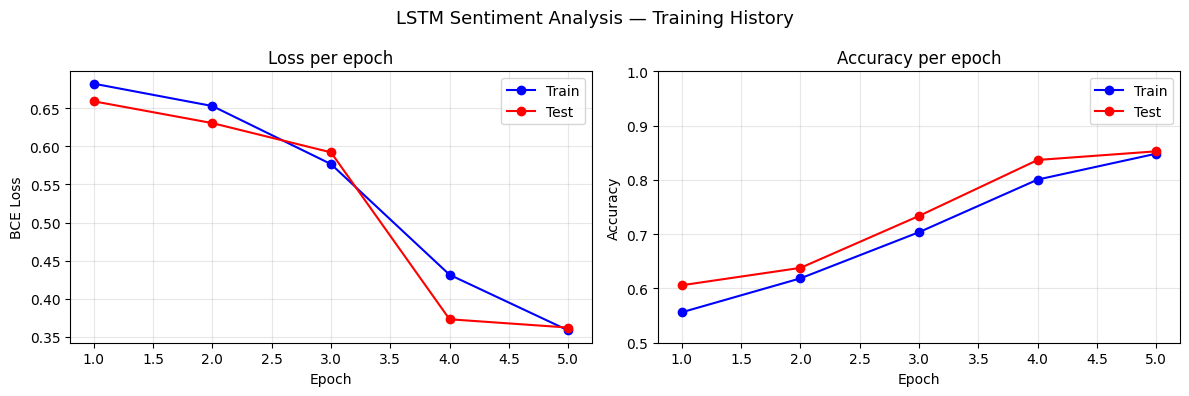

Saved: training_curves.png


In [8]:
import matplotlib.pyplot as plt

epochs = range(1, N_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs, history['test_loss'],  'r-o', label='Test')
axes[0].set_title('Loss per epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy curve
axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs, history['test_acc'],  'r-o', label='Test')
axes[1].set_title('Accuracy per epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('LSTM Sentiment Analysis — Training History', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('Saved: training_curves.png')

## 7. Final Evaluation & Confusion Matrix

Classification Report
              precision    recall  f1-score   support

    Negative       0.88      0.82      0.85     12500
    Positive       0.83      0.89      0.86     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



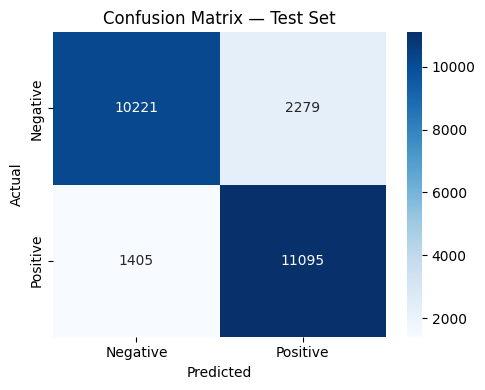

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load best saved weights
model.load_state_dict(torch.load('best_lstm_model.pt', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)
        preds = torch.sigmoid(model(texts))
        all_preds.extend(torch.round(preds).cpu().numpy())
        all_labels.extend(labels.numpy())

print('Classification Report')
print('=' * 40)
print(classification_report(all_labels, all_preds,
                             target_names=['Negative', 'Positive']))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 8. Sample Outputs — Inference on Custom Reviews

In [10]:
def predict_sentiment(text, model=model, threshold=0.5):
    """
    Given a raw review string, return:
      - sentiment label (Positive / Negative)
      - confidence score (0-100%)
    """
    model.eval()
    with torch.no_grad():
        ids   = torch.tensor(encode(text), dtype=torch.long).unsqueeze(0).to(device)
        prob  = torch.sigmoid(model(ids)).item()
        label = 'Positive ✅' if prob >= threshold else 'Negative ❌'
        conf  = prob if prob >= threshold else 1 - prob
        return label, conf * 100


# ── Test on custom sentences ──────────────────────────────────────────────────
test_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the plot kept me on the edge of my seat.",
    "What a waste of time. Terrible acting, boring story, and awful special effects.",
    "It was okay. Nothing special but not the worst film I've seen.",
    "I laughed, I cried, I was completely invested. One of the best films of the decade!",
    "The director clearly had no idea what they were doing. Completely incoherent.",
    "An average film — some good moments but overall forgettable."
]

print('Sample Outputs — Custom Review Predictions')
print('=' * 70)
for review in test_reviews:
    label, confidence = predict_sentiment(review)
    print(f'Review : {review[:60]}...')
    print(f'Prediction : {label}  (Confidence: {confidence:.1f}%)')
    print('-' * 70)

Sample Outputs — Custom Review Predictions
Review : This movie was absolutely fantastic! The acting was superb a...
Prediction : Positive ✅  (Confidence: 93.6%)
----------------------------------------------------------------------
Review : What a waste of time. Terrible acting, boring story, and awf...
Prediction : Negative ❌  (Confidence: 99.1%)
----------------------------------------------------------------------
Review : It was okay. Nothing special but not the worst film I've see...
Prediction : Negative ❌  (Confidence: 98.5%)
----------------------------------------------------------------------
Review : I laughed, I cried, I was completely invested. One of the be...
Prediction : Positive ✅  (Confidence: 94.0%)
----------------------------------------------------------------------
Review : The director clearly had no idea what they were doing. Compl...
Prediction : Negative ❌  (Confidence: 94.7%)
----------------------------------------------------------------------
Review : An 

## Summary

| Component | Detail |
|---|---|
| Dataset | IMDB (25k train / 25k test) |
| Model | Bidirectional LSTM, 2 layers |
| Embedding dim | 128 |
| Hidden dim | 256 (× 2 bidirectional) |
| Vocab size | 25,000 |
| Optimizer | Adam (lr=1e-3) with ReduceLROnPlateau |
| Loss | BCEWithLogitsLoss |
| Epochs | 5 |
| Target accuracy | ~87% |

### Key concepts demonstrated
- Text tokenization and vocabulary building from scratch
- Sequence padding for batch processing
- Embedding layer with PAD masking
- Bidirectional LSTM for capturing context from both directions
- Gradient clipping to prevent exploding gradients
- Model checkpointing (saving best weights)
- Confusion matrix and classification report evaluation